# ZINC Non-Streaming Training and Sampling

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random
import warnings

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))
import torch
torch.set_float32_matmul_precision('high')

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
# zinc.csv has roughly 499k rows. Use 200k for the first larger run;
# set DATA_LIMIT = None to consume the full file.
DATA_LIMIT = None
# The all-pairs edge-count loss scales as batch * max_nodes^2 * latent_dim.
# Batch 256 exceeds a 16 GB-class GPU; 96 keeps the d512 model practical.
FIT_BATCH_SIZE = 96
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10

# Fit SVD bases on a fixed row sample, then project the full dataset.
EMBEDDING_DIM = 512
EMBEDDING_SVD_DIM = 192
EMBEDDING_SVD_FIT_MAX_ROWS = 100_000
EMBEDDING_SVD_TRANSFORM_BATCH_SIZE = 10_000
LEARNING_RATE = 1e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.35

# Capacity knobs. The full-data d384/l8 run still showed no train/validation divergence,
# so increase representation and depth while easing dropout.
NUMBER_OF_TRANSFORMER_LAYERS = 10
TRANSFORMER_ATTENTION_HEAD_COUNT = 8
TRANSFORMER_DROPOUT = 0.05

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

DATA_LIMIT_LABEL = 'all' if DATA_LIMIT is None else DATA_LIMIT
MODEL_NAME = (
    f'{ZINC_SIZE}-d{EMBEDDING_DIM}-svd{EMBEDDING_SVD_DIM}-s{DATA_LIMIT_LABEL}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-l{NUMBER_OF_TRANSFORMER_LAYERS}-h{TRANSFORMER_ATTENTION_HEAD_COUNT}'
    f'-drop{TRANSFORMER_DROPOUT:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
# Keep preprocessing serial for the non-streaming notebook. The parallel
# vectorizer/feasibility path can wedge in long-lived notebook kernels before
# training starts, leaving no useful progress output.
VECTORIZER_PARALLEL = True
FEASIBILITY_PARALLEL = True
FEASIBILITY_N_JOBS = -1
DECODER_N_JOBS = -1
DECODER_SOLVER_THREADS = 16
MAX_DECODE_SECONDS_PER_SAMPLE = 30.0
MAX_DECODE_ATTEMPTS_PER_SAMPLE = 2


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [3]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_SVD_DIM,
    graph_embedding_svd_dimension=EMBEDDING_SVD_DIM,
    embedding_svd_fit_max_rows=EMBEDDING_SVD_FIT_MAX_ROWS,
    embedding_svd_transform_batch_size=EMBEDDING_SVD_TRANSFORM_BATCH_SIZE,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    node_vectorizer_dense=False,
    graph_vectorizer_dense=False,
    node_vectorizer_parallel=VECTORIZER_PARALLEL,
    graph_vectorizer_parallel=VECTORIZER_PARALLEL,
    feasibility_parallel=FEASIBILITY_PARALLEL,
    feasibility_n_jobs=FEASIBILITY_N_JOBS,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    stream_snapshot_every_n_batches=5,
    decoder_n_jobs=DECODER_N_JOBS,
    decoder_solver_threads=DECODER_SOLVER_THREADS,
    max_decode_seconds_per_sample=MAX_DECODE_SECONDS_PER_SAMPLE,
    max_decode_attempts_per_sample=MAX_DECODE_ATTEMPTS_PER_SAMPLE,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
print('node_vectorizer_dense =', graph_generator.node_graph_vectorizer.dense)
print('graph_vectorizer_dense =', graph_generator.graph_vectorizer.dense)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules
graph_generator.graph_decoder.adjacency_time_limit_seconds = MAX_DECODE_SECONDS_PER_SAMPLE
graph_generator.graph_decoder.parallel_decode_timeout_seconds = MAX_DECODE_SECONDS_PER_SAMPLE

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}
TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


ZINC CSV: /cs0eth/home/fc334/code/NodeField/notebooks/datasets/zinc/zinc.csv
Loaded 249455 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc-d512-svd192-sall-b96-lr0-0001-mask0-35-l10-h8-drop0-05-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
node_vectorizer_dense = False
graph_vectorizer_dense = False
Training sample PDF: /cs0eth/home/fc334/code/NodeField/.artifacts/samples/zinc-d512-svd192-sall-b96-lr0.0001-mask0.35-l10-h8-drop0.05-e350/training_samples.pdf


In [ ]:
%%time
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=5,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_kwargs=TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS,
    sample_training_progress_plot_fn=draw_molecule,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=zinc-d512-svd192-sall-b96-lr0-0001-mask0-35-l10-h8-drop0-05-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Fitting model on 249455 graphs
Fitting graph vectorizer on 249455 graphs
Finished fitting graph vectorizer on 249455 graphs in 0m 0.0s
Fitting node graph vectorizer on 249455 graphs
Finished fitting node graph vectorizer on 249455 graphs in 0m 0.0s
Encoding node embeddings for 249455 graphs
Finished encoding node embeddings for 249455 graphs in 9m 53.4s
Encoding graph embeddings for 249455 graphs
Finished encoding graph embeddings for 249455 graphs in 9m 48.3s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(5775223, 2048), sparse=True, nnz=1027259554, density=0.086852.
Prepared graph embedding matrix: shape=(249455, 2048), sparse=True, nnz=241862688, density=0.473420.
Sampled node embedding SVD fit rows: 5775223 -> 100000.
Fitting node embedding SVD on shape=(100000, 2048), spars

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


epoch 1: completed epoch in 3622.99s
epoch 2: completed epoch in 3619.62s
epoch 3: completed epoch in 3652.45s
epoch 4: completed epoch in 3624.59s


In [ ]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc15-nonstreaming-d64-s10000-b128-e350'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.solver_threads = DECODER_SOLVER_THREADS
graph_generator.max_decode_seconds_per_sample = MAX_DECODE_SECONDS_PER_SAMPLE
graph_generator.max_decode_attempts_per_sample = MAX_DECODE_ATTEMPTS_PER_SAMPLE
graph_generator.graph_decoder.adjacency_time_limit_seconds = MAX_DECODE_SECONDS_PER_SAMPLE
graph_generator.graph_decoder.parallel_decode_timeout_seconds = MAX_DECODE_SECONDS_PER_SAMPLE


,name,modified,size_mb
0,zinc-nonstreaming-d384-svd128-sall-b128-lr0-0001-mask0-35-l8-h8-drop0-1-e350.pkl,2026-06-17 15:01,341.000000
1,zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350.pkl,2026-06-13 03:43,161.000000
2,zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-10 21:04,45.100000
3,artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl,2026-06-10 14:54,20.300000
4,artificial-cycle-path-star-n60000-c4-nc2-p2-r2x2-d128-b128-e350.pkl,2026-06-08 13:50,70.900000
5,artificial-cycle-path-star-n6000-c4-nc2-p2-r2x2-d64-b128-e350.pkl,2026-06-05 20:01,8.900000
6,artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:40,8.900000
7,artificial-cycle-path-star-n2500-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:18,7.100000
8,artificial-cycle-path-star-n2500-c3-p2-r2x1-d64-b128-e350.pkl,2026-06-05 17:01,7.100000
9,artificial-cycle-path-star-n5000-c6-nc2-p3-r3x3-d64-b128-e350.pkl,2026-06-05 16:10,8.500000


Loaded graph generator: zinc-nonstreaming-d384-svd128-sall-b128-lr0-0001-mask0-35-l8-h8-drop0-1-e350.pkl
/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators/zinc-nonstreaming-d384-svd128-sall-b128-lr0-0001-mask0-35-l8-h8-drop0-1-e350.pkl


Non-streaming ZINC effort 0 samples


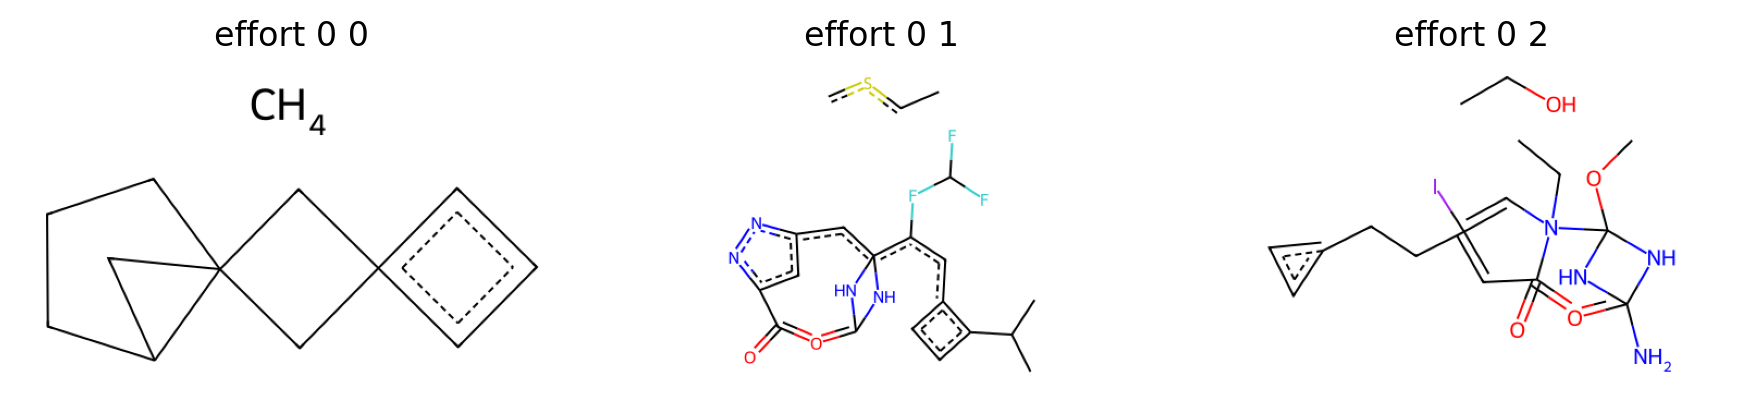

Non-streaming ZINC effort 1 samples


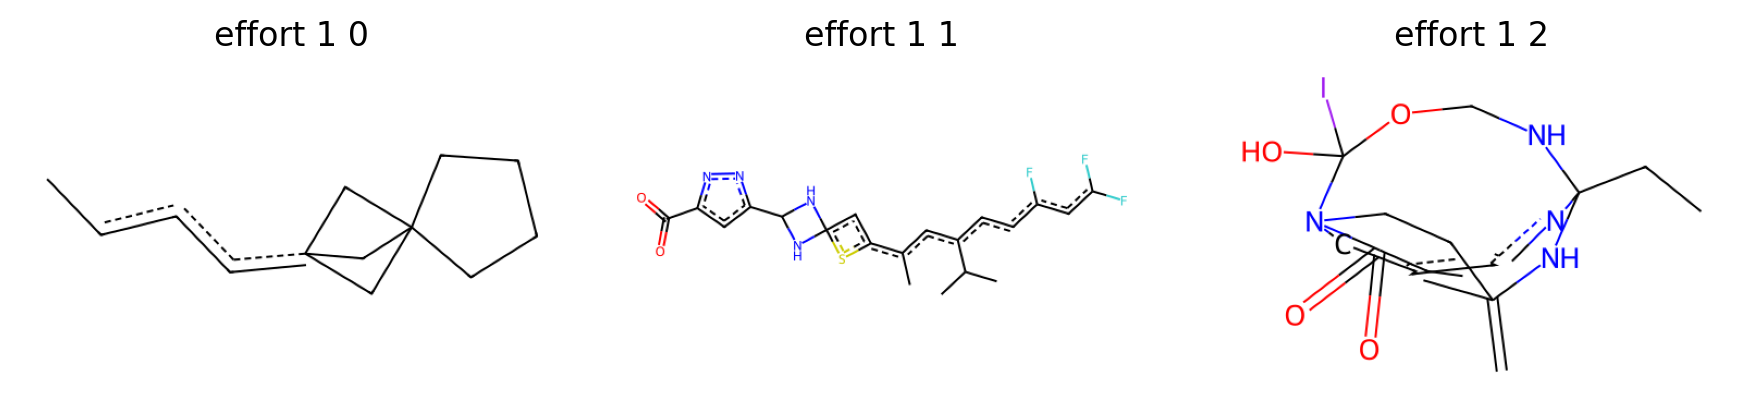

Non-streaming ZINC effort 2 samples


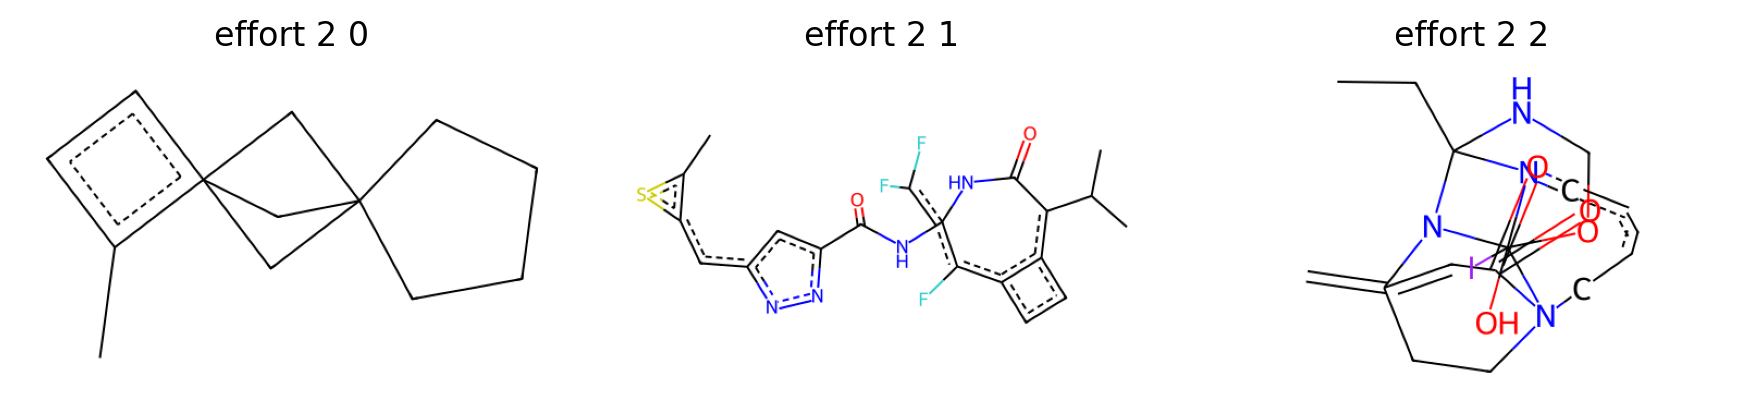

Non-streaming ZINC effort 3 samples


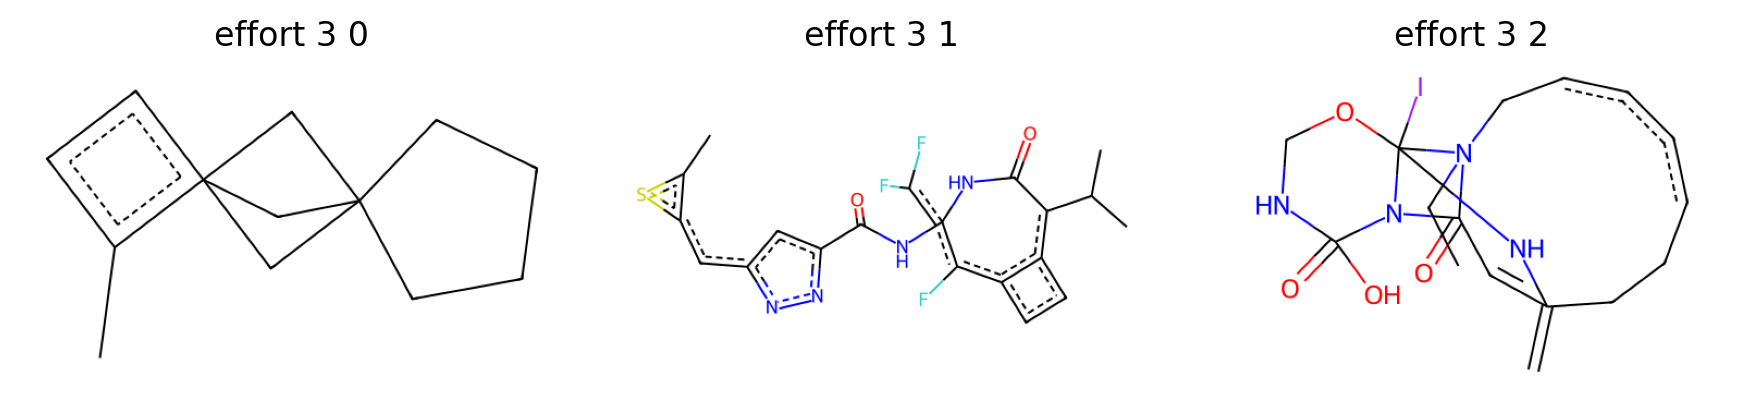

Non-streaming ZINC effort 4 samples


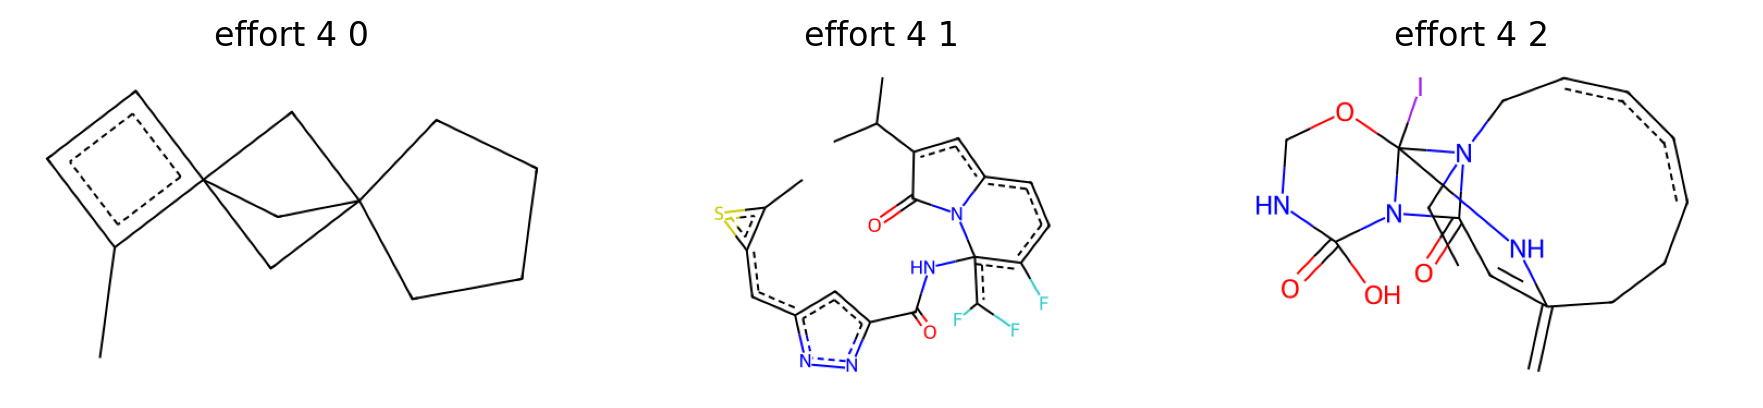

Non-streaming ZINC effort 5 samples


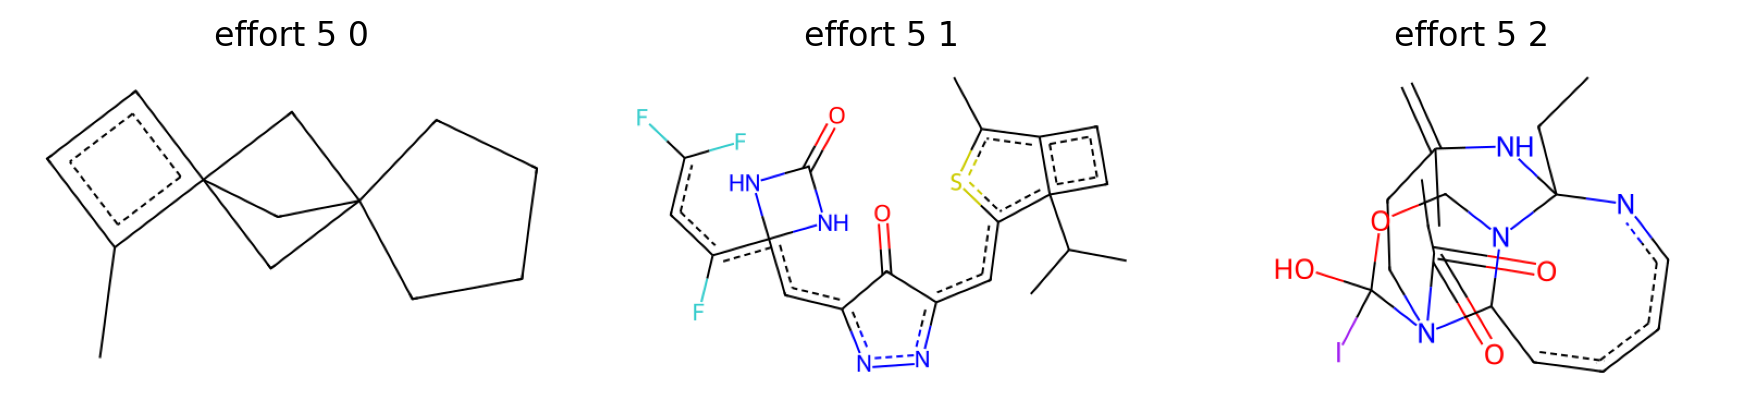

In [ ]:
n_samples = 3
FEASIBILITY_EFFORT = 5
FEASIBILITY_FILTER = 'strict'  # 'none', 'fallback', or 'strict'

sample_variants = graph_generator.sample(
    n_samples=n_samples,
    feasibility_effort=FEASIBILITY_EFFORT,
    return_decode_stages=True,
)
effort_keys = sorted(sample_variants, key=lambda key: int(key.split('_')[1]))

for variant_key in effort_keys:
    effort = int(variant_key.split('_')[1])
    title_prefix = f'effort {effort}'
    variant_samples = [graph for graph in sample_variants[variant_key] if graph is not None]
    if not variant_samples:
        print(f'No {title_prefix} samples to display.')
        continue
    show_molecules(
        variant_samples,
        n=len(variant_samples),
        title=f'Non-streaming ZINC {title_prefix} samples',
        legends=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
        n_graphs_per_line=n_samples,
    )


Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 1 | feasible_rate= 12.5% | attempt_time=16m 54.2s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=1, feasible_rate=12.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=4m 23.0s | eta=1h 23m 16.7s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=7m 12.9s | eta=1h 44m 23.0s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=8m 51.8s | eta=1h 55m 56.9s
Oracle-guided adjacency solve failed with 19 active cuts at iteration 7/16; retrying with fewer cuts.
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=6m 55.9s | eta=1h 49m 34.5s
Feasibility attempt  5/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=9m 08.7s | eta=1

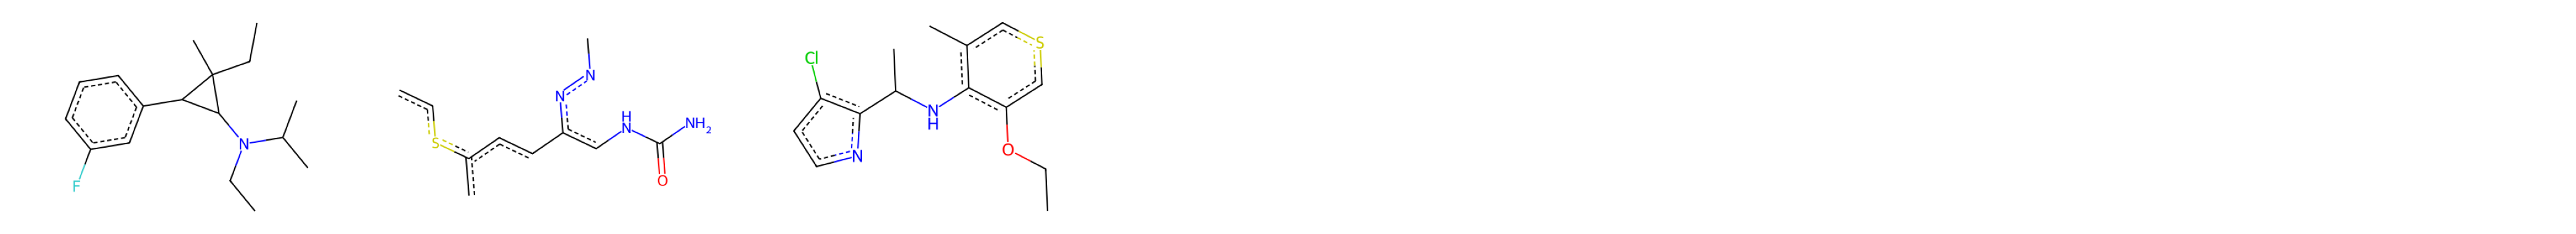

In [ ]:
if graph_generator.feasibility_estimator is None and FEASIBILITY_FILTER != 'none':
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=n_samples,
    feasibility_effort=FEASIBILITY_EFFORT,
    feasibility_filter=FEASIBILITY_FILTER,
)
show_molecules(
    filtered_samples,
    n=len(filtered_samples),
    title=f'Non-streaming ZINC samples | effort={FEASIBILITY_EFFORT}, filter={FEASIBILITY_FILTER}',
    n_graphs_per_line=max(1, n_samples),
)
